 # CS480: Introduction to Quantum Computing

 ## Homework 6: Measurement and Interference

 **Due:** Tuesday 11:59 PM

 **Total Points:** 80



 ### Instructions

 - Complete all exercises in this notebook

 - Run all cells to verify your answers

 - Show your work and explain your reasoning where indicated

 - Submit the completed .ipynb file



 ### This homework covers:

 - Part 1: The Born Rule & State Collapse (15 pts)

 - Part 2: Bases and Observables (20 pts)

 - Part 3: Quantum Interference (25 pts)

 - Part 4: Applications of Interference (10 pts)

 - Part 5: Challenge Problem (10 pts)

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector

sim = AerSimulator()

def run_circuit(qc, shots=1000):
    """Helper function to run a circuit and return counts."""
    job = sim.run(qc, shots=shots)
    return job.result().get_counts()

def get_probabilities(counts, shots=1000):
    """Convert counts to probabilities."""
    return {k: v/shots for k, v in counts.items()}


 ---

 ## Part 1: The Born Rule & State Collapse (15 points)

 ### Exercise 1.1 (5 points)

 **Born Rule with an X-Rotation**



 Create the state $|\psi\rangle = R_x(3\pi/4)|0\rangle$.



 1. Calculate the theoretical probabilities $P(0)$ and $P(1)$ manually (remember $R_x(\theta)|0\rangle = \cos(\theta/2)|0\rangle - i\sin(\theta/2)|1\rangle$).

 2. Simulate the circuit 10,000 times and compare the simulated fractions to the theoretical probabilities.

In [49]:
print("Exercise 1.1: Born Rule Verification")

theta = 3 * np.pi / 4

qc_1_1 = QuantumCircuit(1, 1)
# TODO: Apply the correct Rx rotation and measure in the Z-basis
qc_1_1.rx(theta, 0)
qc_1_1.measure(0, 0)

# TODO: Calculate theoretical probabilities using the Born Rule
P_0_theory = np.cos(theta / 2)**2 # |cos(theta/2)|^2
P_1_theory = np.sin(theta / 2)**2 # |-i*sin(theta/2)|^2

# Run simulation
counts_1_1 = run_circuit(qc_1_1, shots=10000)
probs_1_1 = get_probabilities(counts_1_1, 10000)

print(f"Theoretical P(0): {P_0_theory:.4f} | Simulated P(0): {probs_1_1.get('0', 0):.4f}")
print(f"Theoretical P(1): {P_1_theory:.4f} | Simulated P(1): {probs_1_1.get('1', 0):.4f}")


Exercise 1.1: Born Rule Verification
Theoretical P(0): 0.1464 | Simulated P(0): 0.1476
Theoretical P(1): 0.8536 | Simulated P(1): 0.8524


 ### Exercise 1.2 (5 points)

 **Observing Mathematical State Collapse**



 Prepare the $|-i\rangle$ state (using an $X$ gate, $H$ gate, and $S$ gate).

 We will use `Statevector.measure()` to observe the collapsed state mathematically. Run the cell a few times to see both outcomes!

In [50]:
print("Exercise 1.2: State Collapse")

qc_1_2 = QuantumCircuit(1)
# TODO: Prepare the |-i> state
qc_1_2.x(0)
qc_1_2.h(0)
qc_1_2.s(0)

sv_initial = Statevector(qc_1_2)
print("State before measurement:", np.round(sv_initial.data, 4))

# NOTE: Statevector.measure() is a handy mathematical tool! 
# It simulates a measurement exactly like the `qc.measure()` you are used to, 
# but instead of just giving you counts, it returns a single random outcome 
# AND the newly collapsed mathematical state vector so we can look at it.

# TODO: Use sv_initial.measure() to simulate a single measurement. 
outcome, collapsed_sv = sv_initial.measure()  # sv_initial.measure()

print(f"\nMeasurement Outcome: {outcome}")
print("State AFTER measurement:", np.round(collapsed_sv.data, 4))


Exercise 1.2: State Collapse
State before measurement: [0.7071+0.j     0.    -0.7071j]

Measurement Outcome: 0
State AFTER measurement: [1.+0.j 0.+0.j]


 ### Exercise 1.3 (5 points)

 **3-Qubit Partial Measurement**



 Create the following 3-qubit entangled state: $|\psi\rangle = \frac{1}{\sqrt{2}}(|010\rangle + |101\rangle)$.

 Measure **ONLY** Qubit 1 (the middle qubit) into classical bit 0.

In [51]:
print("Exercise 1.3: 3-Qubit Partial Measurement")

qc_1_3 = QuantumCircuit(3, 1)
# TODO: Create the state (|010> + |101>)/sqrt(2)
# Hint: Start with H on Qubit 0. Use CNOTs to entangle Q1 and Q2.
qc_1_3.h(0)   # create superposition on qubit 0
qc_1_3.x(1)
qc_1_3.cx(0, 1)   # entangle qubit 1 with qubit 0
qc_1_3.cx(0, 2)   # entangle qubit 2 with qubit 0
# TODO: Measure ONLY Qubit 1 into classical bit 0
qc_1_3.measure(1, 0)
counts_1_3 = run_circuit(qc_1_3, shots=1000)
print("Counts (Measuring Qubit 1):", counts_1_3)



Exercise 1.3: 3-Qubit Partial Measurement
Counts (Measuring Qubit 1): {'0': 504, '1': 496}


 ---

 ## Part 2: Bases and Observables (20 points)

 ### Exercise 2.1 (5 points)

 **Measuring $|-\rangle$ in the Y-Basis**



 Write a sequence that measures the specified qubit in the Y-basis.

 Test it by preparing the $|-\rangle$ state and measuring it in the Y-basis. What is the expected distribution?

In [52]:
print("Exercise 2.1: Measuring |-⟩ in Y-basis")

qc_2_1 = QuantumCircuit(1, 1)
# TODO: Prepare the |-⟩ state

# TODO: Apply the Y-basis transformation (S-dagger, then H)

# TODO: Add standard Z-measurement
qc_2_1.x(0)
qc_2_1.h(0)     # |−> = H X |0>
qc_2_1.sdg(0)
qc_2_1.h(0)
qc_2_1.measure(0,0)
counts_2_1 = run_circuit(qc_2_1, shots=10000)
print("Counts:", counts_2_1) 
# Expected: A 50/50 split because |-> is on the X axis, equidistant from the Y axis poles.


Exercise 2.1: Measuring |-⟩ in Y-basis
Counts: {'1': 4965, '0': 5035}


 ### Exercise 2.2 (5 points)

 **X-Basis Measurement of $|\Psi^+\rangle$**



 Create the Bell state $|\Psi^+\rangle = \frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$.

 Measure BOTH qubits in the X-basis.

In [53]:
print("Exercise 2.2: X-Basis Measurement of |Psi+>")

qc_2_2 = QuantumCircuit(2, 2)
# TODO: Prepare the |Psi+> state (H on q0, X on q1, CNOT q0->q1)

# TODO: Apply the X-basis transformation to both qubits

# TODO: Measure both qubits
qc_2_2.h(0)
qc_2_2.x(1)      # start in |01>
qc_2_2.cx(0,1)   # entangle to create |Psi+>
qc_2_2.h(0)      # X-basis rotation
qc_2_2.h(1)
qc_2_2.measure([0,1],[0,1])
counts_2_2 = run_circuit(qc_2_2, shots=10000)
print("Counts:", counts_2_2)


Exercise 2.2: X-Basis Measurement of |Psi+>
Counts: {'11': 5016, '00': 4984}


 ### Exercise 2.3 (5 points)

 **The Hadamard-Phase-Hadamard Transformation**



 Prepare $|0\rangle$. Apply $H \to S \to H$. Measure in the Z-basis.

 Look at the resulting probabilities. Verify that this exact same output distribution from $|0\rangle$ can be created with a single $R_x(\pi/2)$ gate.

In [54]:
print("Exercise 2.3: H -> S -> H")

qc_2_3 = QuantumCircuit(1, 1)
# TODO: Apply H, then S, then H, then measure in Z
qc_2_3.h(0)
qc_2_3.s(0)
qc_2_3.h(0)
qc_2_3.measure(0, 0)

counts_2_3 = run_circuit(qc_2_3, shots=10000)
print("H-S-H Counts:", counts_2_3)

qc_rx = QuantumCircuit(1, 1)
# TODO: Apply Rx(pi/2) to |0> and measure in Z
qc_rx.rx(np.pi / 2, 0)
qc_rx.measure(0, 0)

counts_rx = run_circuit(qc_rx, shots=10000)
print("Rx(pi/2) Counts:", counts_rx)


Exercise 2.3: H -> S -> H
H-S-H Counts: {'1': 4971, '0': 5029}
Rx(pi/2) Counts: {'0': 4996, '1': 5004}


 ### Exercise 2.4 (5 points)

 **Mixed Bell Measurement**



 Create the Bell state $|\Phi^-\rangle = \frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$.

 Measure Qubit 0 in the **X-basis** and Qubit 1 in the **Y-basis**.

In [55]:
print("Exercise 2.4: Mixed Basis Measurement")

qc_2_4 = QuantumCircuit(2, 2)
# TODO: Create Bell state |Phi-> 

# TODO: Transform qubit 0 to X-basis
# TODO: Transform qubit 1 to Y-basis

# TODO: Measure both
qc_2_4.h(0)
qc_2_4.cx(0, 1)
qc_2_4.z(0)

qc_2_4.h(0)

qc_2_4.sdg(1)
qc_2_4.h(1)

qc_2_4.measure([0, 1], [0, 1])

counts_2_4 = run_circuit(qc_2_4, shots=10000)
print("Counts:", counts_2_4)


Exercise 2.4: Mixed Basis Measurement
Counts: {'01': 2518, '11': 2508, '00': 2504, '10': 2470}


 ---

 ## Part 3: Quantum Interference (25 points)

 ### Exercise 3.1 (5 points)

 **Destructive Interference via Z-Gate**



 We know $H \cdot H = I$. But what happens if we insert a $Z$ gate in the middle?

 Build the circuit $H \to Z \to H$ on a qubit initialized to $|0\rangle$ and measure.

In [56]:
print("Exercise 3.1: H -> Z -> H Interference")

qc_3_1 = QuantumCircuit(1, 1)
# TODO: Apply H, then Z, then H, then measure
qc_3_1.h(0)
qc_3_1.z(0)
qc_3_1.h(0)
qc_3_1.measure(0, 0)
counts_3_1 = run_circuit(qc_3_1)
print("Counts:", counts_3_1)
print("Observation: The Z gate changed the relative phase, causing destructive interference on |0>!")


Exercise 3.1: H -> Z -> H Interference
Counts: {'1': 1000}
Observation: The Z gate changed the relative phase, causing destructive interference on |0>!


 ### Exercise 3.2 (5 points)

 **Multi-Path Interference (Grover Diffusion Preview)**



 Prepare the state $|\psi\rangle = \frac{1}{2}(|00\rangle + |01\rangle + |10\rangle - |11\rangle)$.

 Notice the negative phase on the $|11\rangle$ state.

 Now, apply an $H$ gate to BOTH qubits and measure.

In [63]:
print("Exercise 3.2: Multi-Path Interference")

qc_3_2 = QuantumCircuit(2, 2)
# TODO: Prepare the initial state (Hint: Apply H to both, then a CZ gate)

# TODO: Apply H to both qubits (This causes the interference)

# TODO: Measure both qubits
qc_3_2.h(0)
qc_3_2.h(1)
qc_3_2.cz(0,1)   # entangle and add phase
qc_3_2.h(0)      # only first qubit gets H to create interference
qc_3_2.h(1)
qc_3_2.measure([0,1],[0,1])

counts_3_2 = run_circuit(qc_3_2)
print("Counts:", counts_3_2)


Exercise 3.2: Multi-Path Interference
Counts: {'00': 256, '10': 263, '01': 243, '11': 238}


 ### Exercise 3.3 (5 points)

 **MZI with Rx Beam Splitters**



 A Mach-Zehnder Interferometer doesn't *have* to use Hadamards. We can use $R_x(\pi/2)$ gates as our beam splitters.

 Build this circuit: $R_x(\pi/2) \to R_z(\phi) \to R_x(-\pi/2)$.

 Test it with $\phi = 0$ and $\phi = \pi$.

In [65]:
print("Exercise 3.3: Rx Interferometer")

def rx_interferometer(phase):
    qc = QuantumCircuit(1, 1)
    # TODO: Build the circuit using rx(pi/2), rz(phase), and rx(-pi/2)
    qc.rx(np.pi / 2, 0)
    qc.rz(phase, 0)
    qc.rx(-np.pi / 2, 0)
    qc.measure(0, 0)
    return qc

for phi in [0, np.pi]:
    qc_rx = rx_interferometer(phi)
    counts_rx = run_circuit(qc_rx)
    print(f"Phase {phi:.2f}: {counts_rx}")


Exercise 3.3: Rx Interferometer
Phase 0.00: {'0': 1000}
Phase 3.14: {'1': 1000}


 ### Exercise 3.4 (10 points)

 **Plotting an Imperfect MZI**



 Let's see what happens if our second beam splitter in a standard MZI is misaligned.

 Create a circuit: $H \to P(\phi) \to R_y(\pi/2 + 0.4)$.

 Sweep $\phi$ from $0$ to $2\pi$, extract $P(0)$, and plot it. You should see the interference pattern is no longer perfect (it won't hit exactly 0 or 1).

Exercise 3.4: Imperfect MZI Interference Pattern


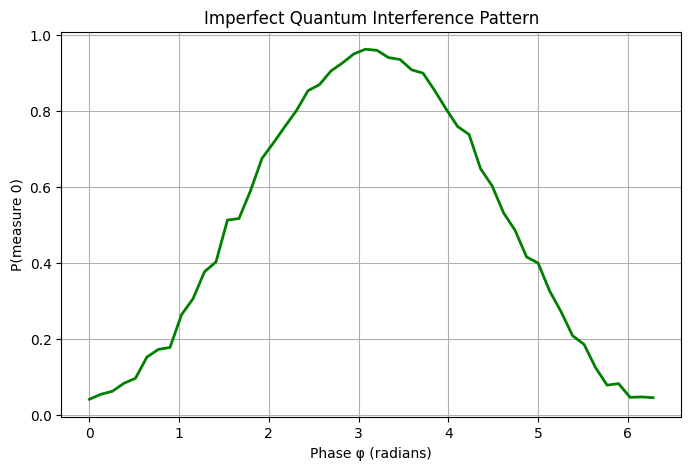

In [59]:
print("Exercise 3.4: Imperfect MZI Interference Pattern")

phases = np.linspace(0, 2*np.pi, 50)
prob_0_list = []

for phi in phases:
    qc_imp = QuantumCircuit(1, 1)
    # TODO: Apply H, then P(phi), then Ry(pi/2 + 0.4)
    # TODO: Measure and extract P(0)
    # prob_0_list.append(...)
    qc_imp.h(0)
    qc_imp.p(phi, 0)
    qc_imp.ry(np.pi / 2 + 0.4, 0)
    qc_imp.measure(0, 0)

    counts_imp = run_circuit(qc_imp, shots=1000)
    prob_0_list.append(counts_imp.get('0', 0) / 1000)

# Plotting code (uncomment when logic above is complete)
# plt.figure(figsize=(8, 5))
# plt.plot(phases, prob_0_list, 'g-', linewidth=2)
# plt.xlabel('Phase φ (radians)')
# plt.ylabel('P(measure 0)')
# plt.title('Imperfect Quantum Interference Pattern')
# plt.grid(True)
# plt.show()
plt.figure(figsize=(8, 5))
plt.plot(phases, prob_0_list, 'g-', linewidth=2)
plt.xlabel('Phase φ (radians)')
plt.ylabel('P(measure 0)')
plt.title('Imperfect Quantum Interference Pattern')
plt.grid(True)
plt.show()


 ---

 ## Part 4: Applications of Interference (10 points)

 ### Exercise 4.1 (10 points)

 **Phase Kickback as Interference**



 1. Apply $H$ to Qubit 0 and $X \to H$ to Qubit 1 (putting Q1 in the $|-\rangle$ state).

 2. Apply a CNOT with Qubit 0 as control and Qubit 1 as target.

 3. Apply an $H$ gate to Qubit 0 to cause interference.

 4. Measure Qubit 0.

In [60]:
print("Exercise 4.1: Phase Kickback")

qc_4_1 = QuantumCircuit(2, 1)
# TODO: Initialize q0 to |+> and q1 to |->

# TODO: Apply CNOT (q0 controls q1)

# TODO: Apply H to q0

# TODO: Measure q0 to classical bit 0
qc_4_1.h(0)

qc_4_1.x(1)
qc_4_1.h(1)

qc_4_1.cx(0, 1)

qc_4_1.h(0)

qc_4_1.measure(0, 0)

counts_4_1 = run_circuit(qc_4_1, shots=1000)
print("Counts (Measuring Q0):", counts_4_1)


Exercise 4.1: Phase Kickback
Counts (Measuring Q0): {'1': 1000}


 **Written Question:** Even though Qubit 0 was the *control* qubit of the CNOT, its final measured state was flipped. Explain how the negative phase of the $|-\rangle$ state "kicked back" and caused destructive interference on Qubit 0.



 YOUR ANSWER:
Qubit 1 starts in the $|-⟩$ state, and the CNOT leaves $|-⟩$ unchanged except for a minus sign when the control qubit is $|1⟩$.  
That minus sign gets attached to the $|1⟩$ part of Qubit 0, so Qubit 0 changes from $|+⟩$ to $|-⟩$.  
After the final Hadamard, $|-⟩$ interferes into $|1⟩$, so the measurement gives 1.


 ---

 ## Part 5: Challenge Problem (10 points)

 ### Challenge 5.1 (10 points)

 **The Quantum Eraser Concept**



 Interference requires indistinguishable paths. If we "mark" the paths by entangling our interfering qubit with a second qubit, we lose the interference pattern. But if we measure the second qubit in the X-basis, we "erase" the path information and the interference comes back!



 1. **Circuit A (Lost Interference):** $H(0) \to CNOT(0 \to 1) \to H(0)$. Measure Q0.

 2. **Circuit B (Erased Information):** $H(0) \to CNOT(0 \to 1) \to H(0)$. Apply $H(1)$ to change Q1 to the X-basis. Measure Q0 and Q1. Look at the counts for Q0 *conditioned* on Q1's outcome.

In [61]:
print("Challenge 5.1: Quantum Eraser Concept")

# Circuit A
qc_A = QuantumCircuit(2, 1)

# TODO: H(0), CNOT(0,1), H(0), Measure(0)
qc_A.h(0)
qc_A.cx(0, 1)
qc_A.h(0)
qc_A.measure(0, 0)
counts_A = run_circuit(qc_A, shots=10000)
print("Circuit A (Q0 results):", counts_A)
# Notice you get a 50/50 split on Q0. The interference pattern is gone because Q1 contains "which path" info!

# Circuit B
qc_B = QuantumCircuit(2, 2)
# TODO: H(0), CNOT(0,1), H(0)
# TODO: H(1)  <-- This "erases" the information by shifting to the X-basis!
# TODO: Measure both
qc_B.h(0)
qc_B.cx(0, 1)
qc_B.h(0)

qc_B.h(1)

qc_B.measure([0, 1], [0, 1])
counts_B = run_circuit(qc_B, shots=10000)
print("\nCircuit B (Q1 Q0 results):", counts_B)


Challenge 5.1: Quantum Eraser Concept
Circuit A (Q0 results): {'0': 4988, '1': 5012}

Circuit B (Q1 Q0 results): {'11': 4890, '00': 5110}


 **Challenge Written Question:**

 In Circuit B, look at the results for Q0 when Q1 was measured as `0`. What about when Q1 was measured as `1`? How does measuring Q1 in the X-basis "restore" the interference pattern on Q0 conditionally?



 YOUR ANSWER:
When Q1 is measured as `0`, the Q0 results collapse to one definite interference branch.  
When Q1 is measured as `1`, Q0 collapses to the opposite interference branch.  
So the overall pattern looks mixed if we ignore Q1, but once we sort the results by the X-basis outcome of Q1, the interference is recovered conditionally because the path information was erased.


 ---

 ## Submission Checklist



 Before submitting, verify:



 - [ ] All code cells run without errors

 - [ ] All TODO sections are completed

 - [ ] Written explanations are provided where requested



 **Grading:**

 - Part 1: 15 points

 - Part 2: 20 points

 - Part 3: 25 points

 - Part 4: 10 points

 - Part 5: 10 points

 - **Total: 80 points**